## Heart Disease Prediction using Logistic Regression

**Importing Libraries**

In [247]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

**Loading Dataset**

In [248]:
data = pd.read_csv("Heart_Disease_Prediction.csv")

**Classification of Gender (1 for Male & 0 for Female)**

In [249]:
data['Sex'] = data['Sex'].map({1: 'M', 0: 'F'})


**Categorizing the inputs and isolation of targets**

In [250]:
X = data[['Age','Sex','Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'ST depression', 'Number of vessels fluro', 'Thallium']]
X = pd.get_dummies(X, columns=['Sex', 'Chest pain type', 'EKG results', 'Thallium'], drop_first=True)
y = np.asarray(data['Heart Disease'])

**Classification of the isolated heart disease data using 0 or 1 (0 if absent else 1)**

In [251]:
y = np.array([1 if val == 'Presence' else 0 for val in y])

**Splitting the data (80% for training and 20% for testing)**

In [252]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Data Standardization**

In [253]:
scaler = StandardScaler()
X_train[['BP', 'Cholesterol', 'Max HR']] = scaler.fit_transform(X_train[['BP', 'Cholesterol', 'Max HR']])
X_test[['BP', 'Cholesterol', 'Max HR']] = scaler.transform(X_test[['BP', 'Cholesterol', 'Max HR']])

**Selection of Logistic Regression model**

In [254]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Prediction**

In [255]:
y_pred = logreg.predict(X_test)

**Checking Accuracy**

In [256]:
#Accuracy
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f"Accuracy of the model: {accuracy}%\n")

# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Recall Score
recall = round(recall_score(y_test, y_pred) * 100, 2)
print(f"\nRecall Score: {recall}%")

Accuracy of the model: 85.19%

Confusion Matrix:
[[33  0]
 [ 8 13]]

Recall Score: 61.9%


**Important Plots**

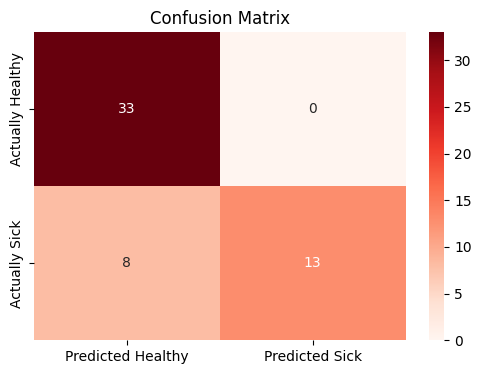

In [257]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Predicted Healthy', 'Predicted Sick'], yticklabels=['Actually Healthy', 'Actually Sick'])

plt.title('Confusion Matrix')
plt.show()

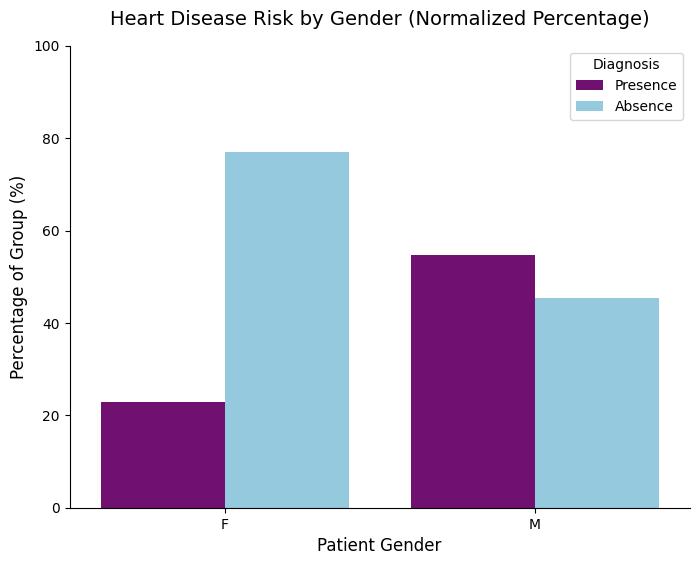

In [259]:
plot_data = data.copy()

gender_percentages = (plot_data.groupby(['Sex', 'Heart Disease'])
                      .size()
                      .unstack()
                      .apply(lambda x: x / x.sum() * 100, axis=1)
                      .reset_index()
                      .melt(id_vars='Sex', var_name='Heart Disease', value_name='Percentage'))

gender_percentages['Heart Disease'] = pd.Categorical(gender_percentages['Heart Disease'], categories=['Presence', 'Absence'], ordered=True)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=gender_percentages,
    x='Sex',
    y='Percentage',
    hue='Heart Disease',
    palette=['Purple', 'SkyBlue'] # Purple for Presence, Sky Blue for Absence
)

plt.title('Heart Disease Risk by Gender (Normalized Percentage)', fontsize=14, pad=15)
plt.xlabel('Patient Gender', fontsize=12)
plt.ylabel('Percentage of Group (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Diagnosis', loc='upper right')
sns.despine()

plt.show()

## Conclusion

Based on the dataset collected from Kaggle, 23% of Females have Heart Disease and 55% of Males have Heart Disease.

Dataset Source: https://www.kaggle.com/datasets/rishidamarla/heart-disease-prediction

We have used the linear model named 'Logistic Regression' for the prediction of heart disease. The overall accuracy, recall score, and the confusion matrix are discussed above.

With a random state of 42, the model achieved 85.19% accuracy, but a recall score of 61.9%.